## Bayesian Causal Forest for HTE
**Model**: BCF for binary outcomes (probit link): model baseline μ(X) and treatment effect surface τ(X) with treatment A and include PS p(X) (or logit PS) as a covariate to correct for targeted selection.

- $\mu(x_i, \pi_i)$ = the **prognostic function** — captures baseline outcome risk, regardless of treatment. $\pi_i$ are the propensity score estimates.
- $\tau(x_i)$ = the **treatment effect function** — captures how the treatment effect varies with covariates (this is CATE)
- $T \in {0,1}$ is the treatment indicator

In [1]:
import os
import sys
import seaborn as sns
from scipy.stats import norm
import pymc as pm
import pymc_bart as pmb
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from ISYE6420.Project.bcf_vis import build_ite_rd, plot_gates, build_clan_table, print_clan_table
rng = np.random.default_rng(123)

output_folder = "ISYE6420/Project/"

## Data Loading and Preparation

In [2]:
# Import configurations
dx_name = "asthma"
version = "v7_040226"

cohort = pd.read_csv(f"ISYE6420\\Project\\data\\{dx_name}_weighted_cohort.csv")
print(len(cohort))


65417


In [3]:
y = cohort["outcome"].values
treatment = cohort["exposure"].values
follow_up_time = cohort["follow_up_time"].values
# Convert to binary indicator for outcome
y_data = (y > 0).astype(int)


### 1. Prognostic Model $\mu(X, \hat{p})$

In [4]:
X = cohort.drop(columns=["patid", "outcome", "exposure", "follow_up_time", "weight", "ps_score"])
# convert True False columns to int
X = X.astype(int)
# Logit transform the propensity scores for better modeling
propensity_score = cohort["ps_score"]
eps = 1e-6
ps_values = np.clip(propensity_score, eps, 1 - eps)
logit_ps = np.log(ps_values / (1 - ps_values))
X['logit_ps'] = logit_ps
X_mu = X.values

prognostic_model_config = {
    "n_trees": 200,
    "beta_prior": 2,
    "alpha_prior": 0.95,
}

In [5]:
num_exac_pats = cohort[cohort['outcome'] > 0]['patid'].nunique()/ cohort['patid'].nunique()
print(f"Proportion of patients with at least one event: {num_exac_pats:.2%}")

Proportion of patients with at least one event: 5.51%


In [6]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

### 2. $\tau$(X) Treatment Effect Model


In [7]:
# Treatment indicator as int
T = treatment.astype(int)

# Feature matrix for tau: same covariates as mu, but add treatment indicator instead of propensity score
#X["T"] = T
X_tau = X.values.astype(float)

tau_model_config = {
    "n_trees": 50,       # stronger regularisation toward zero for treatment effects
    "beta_prior": 3,     # more shrinkage towards homogenenous treatment effects
    "alpha_prior": 0.25,
}


## 3. Run BCF Model

In [8]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

    trace_bcf = pm.sample(2000, tune=6000, nuts_sampler_kwargs={"target_accept": 0.9}, random_seed=rng, chains=4)

ppc = pm.sample_posterior_predictive(trace_bcf, model=bcf_joint)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>PGBART: [mu]
>PGBART: [tau]


Output()

Sampling 4 chains for 6_000 tune and 2_000 draw iterations (24_000 + 8_000 draws total) took 23870 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_likelihood]


Output()

In [9]:
# Extract CATTs from joint model
mu_joint  = trace_bcf.posterior["mu"].mean(dim=["chain", "draw"]).values
tau_joint = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
tau_joint_sd = trace_bcf.posterior["tau"].std(dim=["chain", "draw"]).values

print(f"Joint CATT summary — mean: {tau_joint.mean():.4f}, sd: {tau_joint.std():.4f}")
print(f"ATT (treated only): {tau_joint[T == 1].mean():.4f}")

Joint CATT summary — mean: -0.0707, sd: 0.0779
ATT (treated only): -0.0490


In [10]:
az.to_netcdf(trace_bcf, f"{output_folder}bcf_{dx_name}_binary_ex.nc")

'ISYE6420/Project/bcf_asthma_binary_ex.nc'

In [11]:
zero_ppc = (ppc.posterior_predictive["y_likelihood"] == 0).mean(dim=["chain", "draw"])
print(zero_ppc.values.mean())  # compare to actual zero rate

0.9464415633550912


In [12]:
summary = az.summary(trace_bcf, var_names=["tau"], filter_vars="like")
print(summary[summary["r_hat"] > 1.01].head(20))
print(f"\nMedian ESS (bulk): {summary['ess_bulk'].median():.0f}")
print(f"Patients with ESS < 100: {(summary['ess_bulk'] < 100).sum()}")

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau[0]  -0.121  0.079  -0.279    0.022      0.003    0.001     999.0   
tau[2]  -0.023  0.095  -0.194    0.159      0.016    0.002      35.0   
tau[3]   0.056  0.090  -0.115    0.227      0.011    0.002      64.0   
tau[4]  -0.102  0.089  -0.277    0.057      0.003    0.002     957.0   
tau[5]  -0.084  0.086  -0.244    0.080      0.003    0.002     893.0   
tau[6]  -0.140  0.092  -0.321    0.028      0.003    0.002     985.0   
tau[8]  -0.056  0.090  -0.227    0.112      0.004    0.002     409.0   
tau[9]  -0.202  0.089  -0.374   -0.036      0.003    0.002     948.0   
tau[12] -0.034  0.088  -0.208    0.121      0.003    0.002     871.0   
tau[13] -0.019  0.089  -0.182    0.150      0.003    0.002    1001.0   
tau[14]  0.013  0.088  -0.149    0.182      0.003    0.002     990.0   
tau[15]  0.026  0.090  -0.139    0.202      0.006    0.002     220.0   
tau[16] -0.028  0.089  -0.197    0.141      0.003    0.002     9

## Load existing trace and compute CATE estimates

In [8]:
#Load trace from nc file
trace_bcf = az.from_netcdf(f"{output_folder}bcf_{dx_name}_binary_ex.nc")

In [9]:
with pm.Model() as bcf_joint:

    X_mu_shared  = pm.Data("X_mu",  X_mu)
    X_tau_shared = pm.Data("X_tau", X_tau)
    T_shared = pm.Data("T", T.astype(float))
    y_obs = pm.Data("y_obs", y_data)
    offset = pm.Data("offset", follow_up_time)

    # Prognosis model
    mu = pmb.BART(
        "mu",
        X_mu_shared,
        y_data.astype(float),
        m=prognostic_model_config["n_trees"],
        alpha=prognostic_model_config["alpha_prior"],
        beta=prognostic_model_config["beta_prior"],
        response="constant"
    )

    # Treatment effect
    tau = pmb.BART(
        "tau",
        X_tau_shared,
        y_data.astype(float),
        m=tau_model_config["n_trees"],
        alpha=tau_model_config["alpha_prior"],
        beta=tau_model_config["beta_prior"],
        response="constant"
    )

    # # Use a tight intercept prior to ensure the model starts with a reasonable baseline risk
    constant_intercept = norm.ppf(num_exac_pats)

    # The Latent Propensity
    eta = mu + tau * T_shared + constant_intercept
    
    # Bernoulli Likelihood with Probit link
    p = pm.math.invprobit(eta)
    y_likelihood = pm.Bernoulli("y_likelihood", p=p, observed=y_obs)

# Now you can run PPC using the trace loaded from the .nc file
with bcf_joint:
    ppc = pm.sample_posterior_predictive(trace_bcf)

Sampling: [y_likelihood]


Output()

In [10]:
from scipy.special import ndtr
mu_samples = trace_bcf.posterior['mu'].values.reshape(-1, X_mu.shape[0])
tau_samples = trace_bcf.posterior['tau'].values.reshape(-1, X_tau.shape[0])

# 1. Reconstruct latent probit scores
# Control state (counterfactual for treated, factual for control)
eta_0 = mu_samples + constant_intercept
# Treated state (factual for treated, counterfactual for control)
eta_1 = mu_samples + tau_samples + constant_intercept 

# 2. Map through Standard Normal CDF to get Absolute Risks (Probabilities)
risk_0 = ndtr(eta_0)
risk_1 = ndtr(eta_1)

# 3. Calculate Individual Treatment Effects (ITE) on Risk Difference and Risk Ratio scales
ite_rd = risk_1 - risk_0
ite_rr = risk_1 / risk_0
    
# 4. Filter for Treated Patients to isolate the CATT
# Assuming `treated_indices` is a boolean mask or list of indices where Z == 1
treated_indices = (T == 1)
rd_treated = ite_rd[:, treated_indices]
rr_treated = ite_rr[:, treated_indices]

# Calculate Posterior ATT (Mean and 95% HDI)
catt_rd_posterior = rd_treated.mean(axis=1)

print(f"ATT (Risk Difference) Mean: {catt_rd_posterior.mean():.4f}")
print(f"ATT (Risk Difference) 95% HDI: [{np.quantile(catt_rd_posterior, 0.025):.4f}, {np.quantile(catt_rd_posterior, 0.975):.4f}]")

ATT (Risk Difference) Mean: -0.0046
ATT (Risk Difference) 95% HDI: [-0.0086, -0.0006]


## Goodness of Fit Check

Text(0.5, 1.0, 'Comparison in Log-Space')

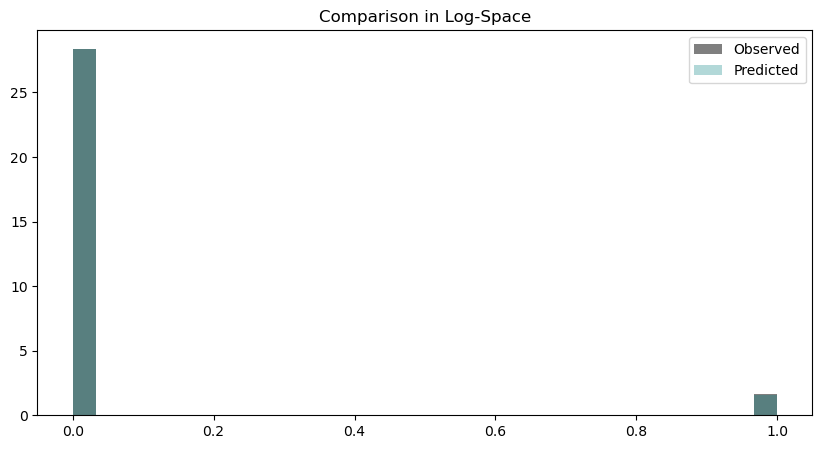

In [12]:
# Manually plot the log of the observed vs predicted
plt.figure(figsize=(10, 5))
plt.hist(y_data, bins=30, density=True, alpha=0.5, label="Observed", color="black")

# Pull a few samples from the posterior predictive
pp_counts = ppc.posterior_predictive["y_likelihood"].values.flatten()
plt.hist(pp_counts, bins=30, density=True, alpha=0.3, label="Predicted", color="teal")

plt.legend()
plt.title("Comparison in Log-Space")

## Visualising Treatment Effects

Text(0.5, 1.0, 'Distribution of Individual Treatment Effects')

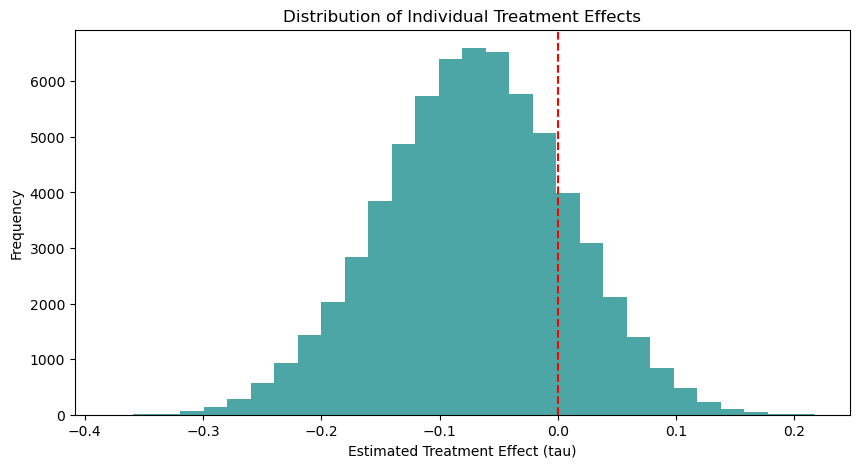

In [13]:
# Visualize the distribution of the Individual Treatment Effects (ITE)
# We take the mean of tau across the posterior samples for each observation
ite_means = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"])

plt.figure(figsize=(10, 5))
plt.hist(ite_means, bins=30, color="teal", alpha=0.7)
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Estimated Treatment Effect (tau)")
plt.ylabel("Frequency")
plt.title("Distribution of Individual Treatment Effects")

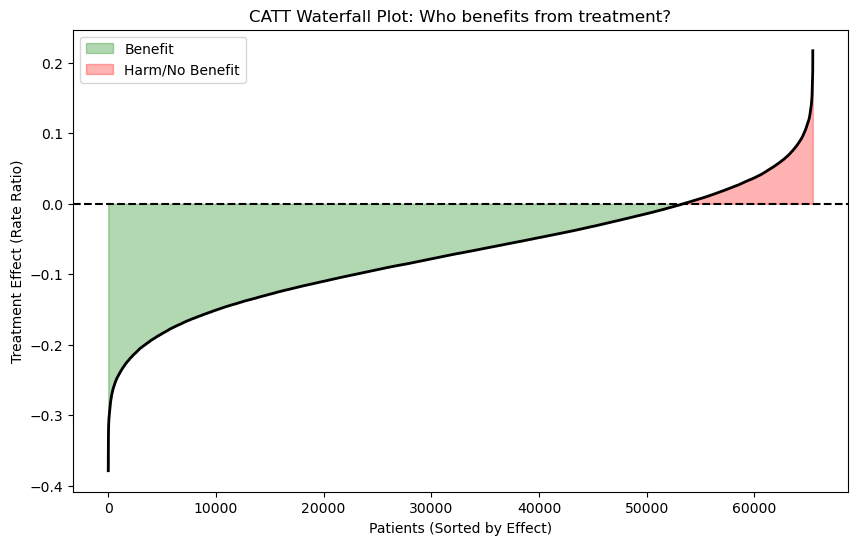

In [14]:
# 1. Get the mean Tau for each of the 20,500 observations
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values

# 2. Sort them
sorted_catt = np.sort(catt_estimates)
index = np.arange(len(sorted_catt))

plt.figure(figsize=(10, 6))
plt.fill_between(index, 0, sorted_catt, where=(sorted_catt < 0), color='green', alpha=0.3, label='Benefit')
plt.fill_between(index, 0, sorted_catt, where=(sorted_catt > 0), color='red', alpha=0.3, label='Harm/No Benefit')
plt.plot(index, sorted_catt, color='black', linewidth=2)
plt.axhline(0, color='black', linestyle='--')
plt.ylabel("Treatment Effect (Rate Ratio)")
plt.xlabel("Patients (Sorted by Effect)")
plt.title("CATT Waterfall Plot: Who benefits from treatment?")
plt.legend()
plt.show()

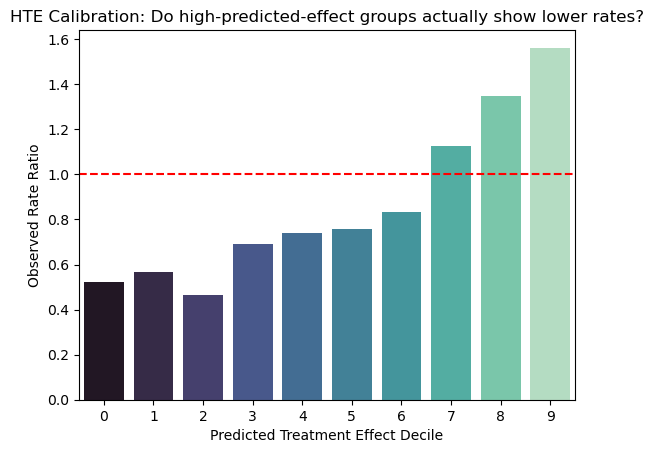

In [15]:
# Create a DataFrame with predicted tau and actual outcomes
df_eval = pd.DataFrame({
    'pred_tau': catt_estimates,
    'observed_y': y_data,
    'T': T
})

# Bin by predicted effect deciles
df_eval['decile'] = pd.qcut(df_eval['pred_tau'], 10, labels=False)

# Calculate observed Rate Ratio per decile
# (Rate in Treated / Rate in Control)
summary_stats = df_eval.groupby('decile').apply(
    lambda x: (x[x['T']==1]['observed_y'].mean()) / (x[x['T']==0]['observed_y'].mean())
)

sns.barplot(x=summary_stats.index, y=summary_stats.values, palette="mako")
plt.axhline(1, color='red', linestyle='--')
plt.ylabel("Observed Rate Ratio")
plt.xlabel("Predicted Treatment Effect Decile")
plt.title("HTE Calibration: Do high-predicted-effect groups actually show lower rates?")
plt.show()

## Interpretable Outputs

In [10]:
def get_tau_samples(trace):
    """Flatten posterior tau samples → (total_draws, N)"""
    tau = trace.posterior["tau"].values          # (chains, draws, N)
    return tau.reshape(-1, tau.shape[-1])        # (4000, N)

def cate_summary(tau_flat, idx):
    """Return (mean, lo94, hi94, P(tau>0)) for a subgroup index array."""
    draws = tau_flat[:, idx].mean(axis=1)        # (total_draws,) — CATE posterior
    hdi = az.hdi(draws, hdi_prob=0.94)
    return draws.mean(), hdi[0], hdi[1], (draws > 0).mean()

In [11]:
# 1. Individual Level IRRs
tau_samples = get_tau_samples(trace_bcf) 
irr_samples = np.exp(tau_samples)

# Calculate Posterior Mean and 95% HDI for each patient
irr_mean = irr_samples.mean(axis=(0, 1))
irr_hdi = az.hdi(irr_samples, hdi_prob=0.95)

# 2. Overall CATT (on log-rate scale first, then summarized)
# Filter tau for treated patients only (T=1)
treated_indices = np.where(T == 1)[0]
catt_samples = tau_samples[:, treated_indices].mean(axis=1)  # (total_draws,) — CATT posterior for treated

catt_mean = catt_samples.mean()
catt_hdi = az.hdi(catt_samples, hdi_prob=0.95)

print(f"Overall CATT (log-scale): {catt_mean:.3f} 95% HDI {catt_hdi}")
print(f"Overall CATT (IRR scale): {np.exp(catt_mean):.3f}")

Overall CATT (log-scale): -0.049 95% HDI [-0.08978756 -0.0054561 ]
Overall CATT (IRR scale): 0.952


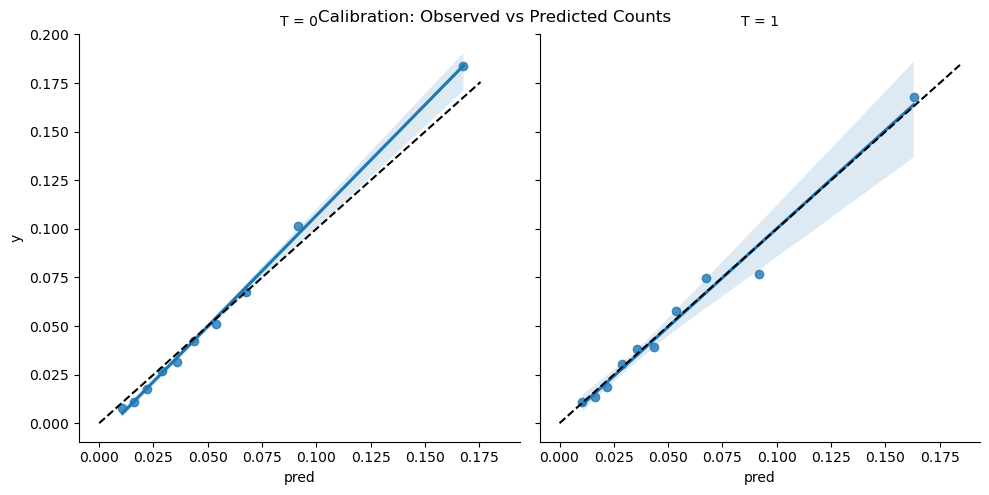

In [12]:
y_pred_mean = ppc.posterior_predictive["y_likelihood"].mean(axis=(0, 1)).values

def plot_calibration(y_true, y_pred, treatment, title):
    df_cal = pd.DataFrame({'y': y_true, 'pred': y_pred, 'T': treatment})
    df_cal['decile'] = pd.qcut(df_cal['pred'], 10, labels=False, duplicates='drop')
    
    cal_data = df_cal.groupby(['T', 'decile']).agg({'y': 'mean', 'pred': 'mean'}).reset_index()
    
    sns.lmplot(data=cal_data, x='pred', y='y', col='T')
    for ax in plt.gcf().axes:
        ax.plot([0, ax.get_xlim()[1]], [0, ax.get_xlim()[1]], 'k--')
    plt.suptitle(title)

plot_calibration(y_data, y_pred_mean, T, "Calibration: Observed vs Predicted Counts")

In [13]:
# ── Extract posterior tau samples ────────────────────────────────────────────
# Shape: (chains, draws, n_obs) → flatten to (draws_total, n_obs)
tau_samples = trace_bcf.posterior["tau"].values          # (4, 1000, N)
tau_flat    = tau_samples.reshape(-1, tau_samples.shape[-1])  # (4000, N)
tau_mean    = tau_flat.mean(axis=0)                      # (N,)
tau_hdi     = az.hdi(tau_flat, hdi_prob=0.95)            # (N, 2)

mu_samples  = trace_bcf.posterior["mu"].values
mu_flat     = mu_samples.reshape(-1, mu_samples.shape[-1])
mu_mean     = mu_flat.mean(axis=0)

# Separate treated / control
treated_idx  = np.where(T == 1)[0]
control_idx  = np.where(T == 0)[0]

ATT = tau_flat[:, treated_idx].mean(axis=1)   # (draws,) — ATT distribution
ATE = tau_flat.mean(axis=1)                   # (draws,) — ATE distribution

In [14]:
att_draws = tau_flat[:, treated_idx].mean(axis=1)
print(f"ATT ESS: {az.ess(att_draws):.0f}")
print(f"ATT Rhat: {az.rhat(att_draws.reshape(4, -1)):.4f}")

ATT ESS: 2914
ATT Rhat: 1.0062


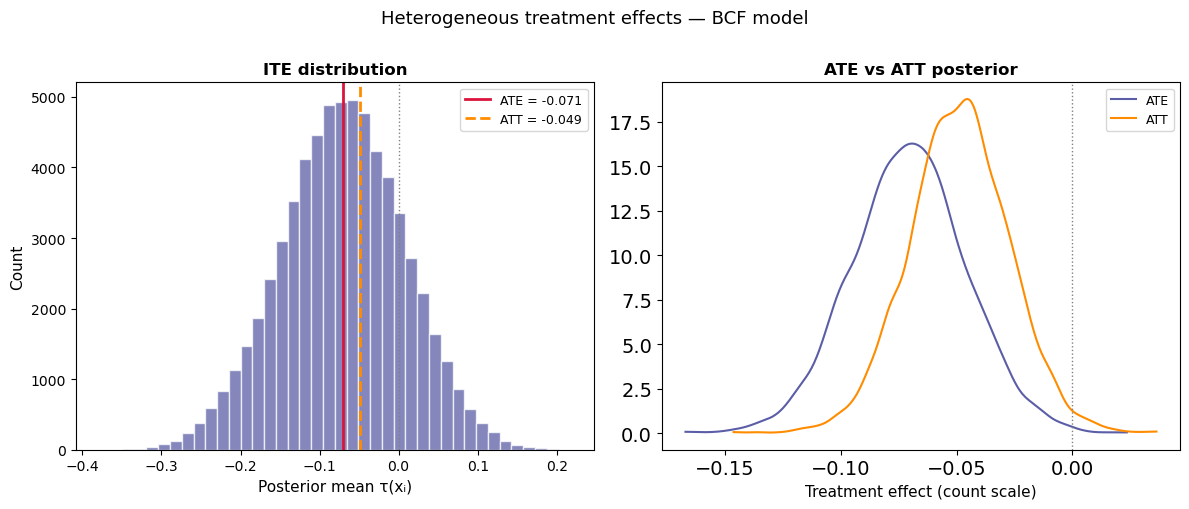

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — ITE distribution + ATT/ATE summary
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of posterior-mean ITEs
ax = axes[0]
ax.hist(tau_mean, bins=40, color="#5B5EA6", alpha=0.75, edgecolor="white")
ax.axvline(tau_mean.mean(), color="crimson", lw=2, label=f"ATE = {tau_mean.mean():.3f}")
ax.axvline(tau_mean[treated_idx].mean(), color="darkorange", lw=2,
           linestyle="--", label=f"ATT = {tau_mean[treated_idx].mean():.3f}")
ax.axvline(0, color="gray", lw=1, linestyle=":")
ax.set_xlabel("Posterior mean τ(xᵢ)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("ITE distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

# Right: ATE vs ATT posterior distributions
ax = axes[1]
az.plot_dist(ATE, label="ATE", color="#5B5EA6", ax=ax)
az.plot_dist(ATT, label="ATT", color="darkorange", ax=ax)
ax.axvline(0, color="gray", lw=1, linestyle=":")
ax.set_xlabel("Treatment effect (count scale)", fontsize=11)
ax.set_title("ATE vs ATT posterior", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

fig.suptitle("Heterogeneous treatment effects — BCF model", fontsize=13, y=1.01)
fig.tight_layout()
#plt.savefig("fig1_ite_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

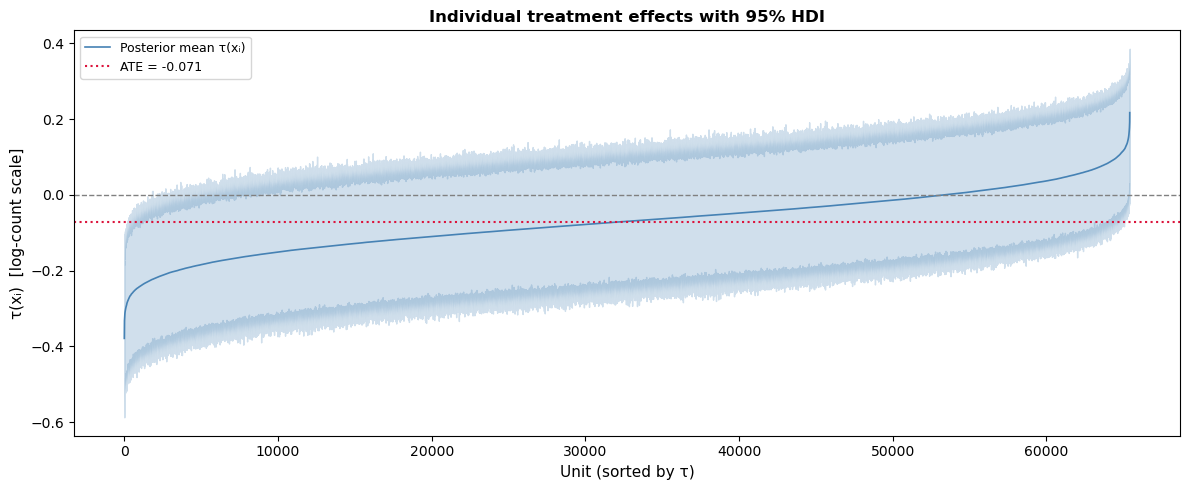

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Credible-interval caterpillar plot (sorted by τ mean)
# ═══════════════════════════════════════════════════════════════════════════
sort_idx = np.argsort(tau_mean)
tau_sorted_mean = tau_mean[sort_idx]
tau_sorted_lo   = tau_hdi[sort_idx, 0]
tau_sorted_hi   = tau_hdi[sort_idx, 1]

fig, ax = plt.subplots(figsize=(12, 5))
n = len(tau_sorted_mean)
xs = np.arange(n)

ax.fill_between(xs, tau_sorted_lo, tau_sorted_hi, alpha=0.25, color="steelblue")
ax.plot(xs, tau_sorted_mean, lw=1.2, color="steelblue", label="Posterior mean τ(xᵢ)")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.axhline(tau_mean.mean(), color="crimson", lw=1.5, linestyle=":", label=f"ATE = {tau_mean.mean():.3f}")
ax.set_xlabel("Unit (sorted by τ)", fontsize=11)
ax.set_ylabel("τ(xᵢ)  [log-count scale]", fontsize=11)
ax.set_title("Individual treatment effects with 95% HDI", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


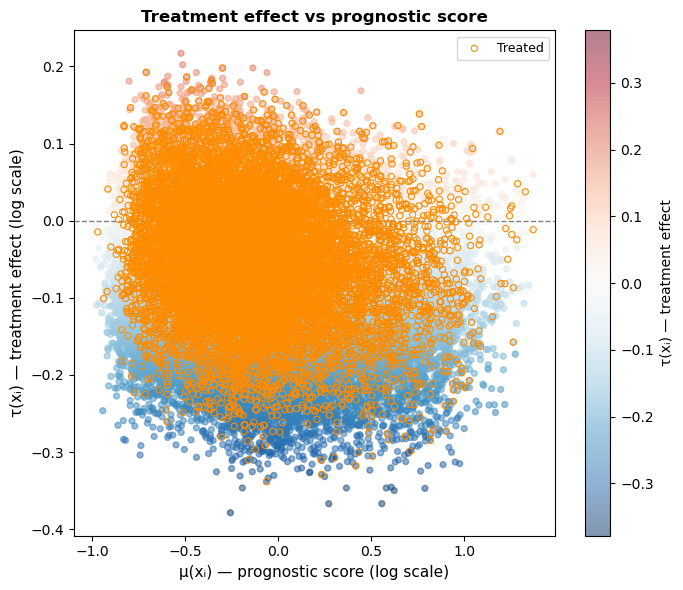

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(mu_mean, tau_mean, c=tau_mean, cmap="RdBu_r",
                alpha=0.5, s=18, vmin=-np.abs(tau_mean).max(), vmax=np.abs(tau_mean).max())
plt.colorbar(sc, ax=ax, label="τ(xᵢ) — treatment effect")
ax.axhline(0, color="gray", lw=1, linestyle="--")
ax.set_xlabel("μ(xᵢ) — prognostic score (log scale)", fontsize=11)
ax.set_ylabel("τ(xᵢ) — treatment effect (log scale)", fontsize=11)
ax.set_title("Treatment effect vs prognostic score", fontsize=12, fontweight="bold")
# Colour by treatment status for extra clarity
ax.scatter(mu_mean[treated_idx], tau_mean[treated_idx],
           s=20, edgecolors="darkorange", facecolors="none", lw=0.8, label="Treated", zorder=5)
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("fig5_tau_vs_mu.png", dpi=150, bbox_inches="tight")
plt.show()

## Subgroup CATTs

In [18]:
# Forest plot for multiple covariates
def plot_forest_multiple(trace, X, feature_names, ax=None, color="#5B5EA6"):
    """
    Parameters
    ----------
    covariate_array : 1-D array of category labels/codes for each covariate (e.g. age group, comorbidity count group, etc.)
    """
    tau_flat = get_tau_samples(trace)
    feature_idx = [X.columns.get_loc(col) for col in feature_names]
    rows = []
    for feat in feature_idx:
        covariate_array = X.iloc[:, feat].to_numpy()
        idx = np.where(covariate_array == 1)[0]
        mean, lo94, hi94, p_pos = cate_summary(tau_flat, idx)
        # Also compute 50% HDI for inner band
        draws_lv = tau_flat[:, idx].mean(axis=1)
        lo50, hi50 = az.hdi(draws_lv, hdi_prob=0.50)
        rows.append(dict(n=len(idx),
                         mean=mean, lo94=lo94, hi94=hi94,
                         lo50=lo50, hi50=hi50, p_pos=p_pos))

    df = pd.DataFrame(rows, index=feature_names)      

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 1.2 * len(df) + 1.5))

    y_pos = np.arange(len(df))[::-1]            # top = first level

    for i, (_, row) in enumerate(df.iterrows()):
        y = y_pos[i]
        # 94% HDI — thin line
        ax.plot([row.lo94, row.hi94], [y, y], lw=1.5,
                color=color, alpha=0.5, solid_capstyle="round")
        # 50% HDI — thick line
        ax.plot([row.lo50, row.hi50], [y, y], lw=5,
                color=color, alpha=0.7, solid_capstyle="round")
        # Posterior mean dot
        ax.scatter(row["mean"], y, s=60, color=color,
                   zorder=5, edgecolors="white", linewidths=0.8)
        # P(τ > 0) annotation on right
        ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] != 0 else row.hi94 + 0.01,
                y, f"  P(τ>0)={row.p_pos:.2f}  n={row.n}",
                va="center", fontsize=8.5, color="gray")

    ax.axvline(0, color="gray", lw=1, linestyle="--", alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df.index, fontsize=10)
    ax.set_xlabel("CATT — posterior mean τ  [log-count scale]", fontsize=10)
    ax.set_title(f"CATT by Multiple Covariates", fontsize=12, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

    return ax, df

In [19]:
X.columns

Index(['age', 'gina_step', 'total_exac_count', 'num_treatments_baseline',
       'num_outpatient_event', 'num_er_event', 'hba1c_missing',
       'atopic_disease_flag', 'ckd_flag', 'dyslipidemia_flag',
       'eosinophilic_disease_flag', 'heart_failure_flag', 'hypertension_flag',
       'ischemic_stroke_flag', 'nasal_polyps_flag',
       'obstructive_sleep_apnea_flag', 't2dm_flag', 'bmi_20_25',
       'bmi_above_25', 'bmi_present', 'Acute_IHD_flag', 'CAD_flag', 'PVD_flag',
       'Biologics_flag', 'ICS_flag', 'ICS_LABA_flag', 'ICS_LABA_LAMA_flag',
       'LTRA_flag', 'OCS_flag', 'SABA_flag', 'SABA_SAMA_flag', 'sex_Female',
       'region_Midwest', 'region_Northeast', 'region_South',
       'region_Southwest', 'region_West', 'logit_ps'],
      dtype='str')

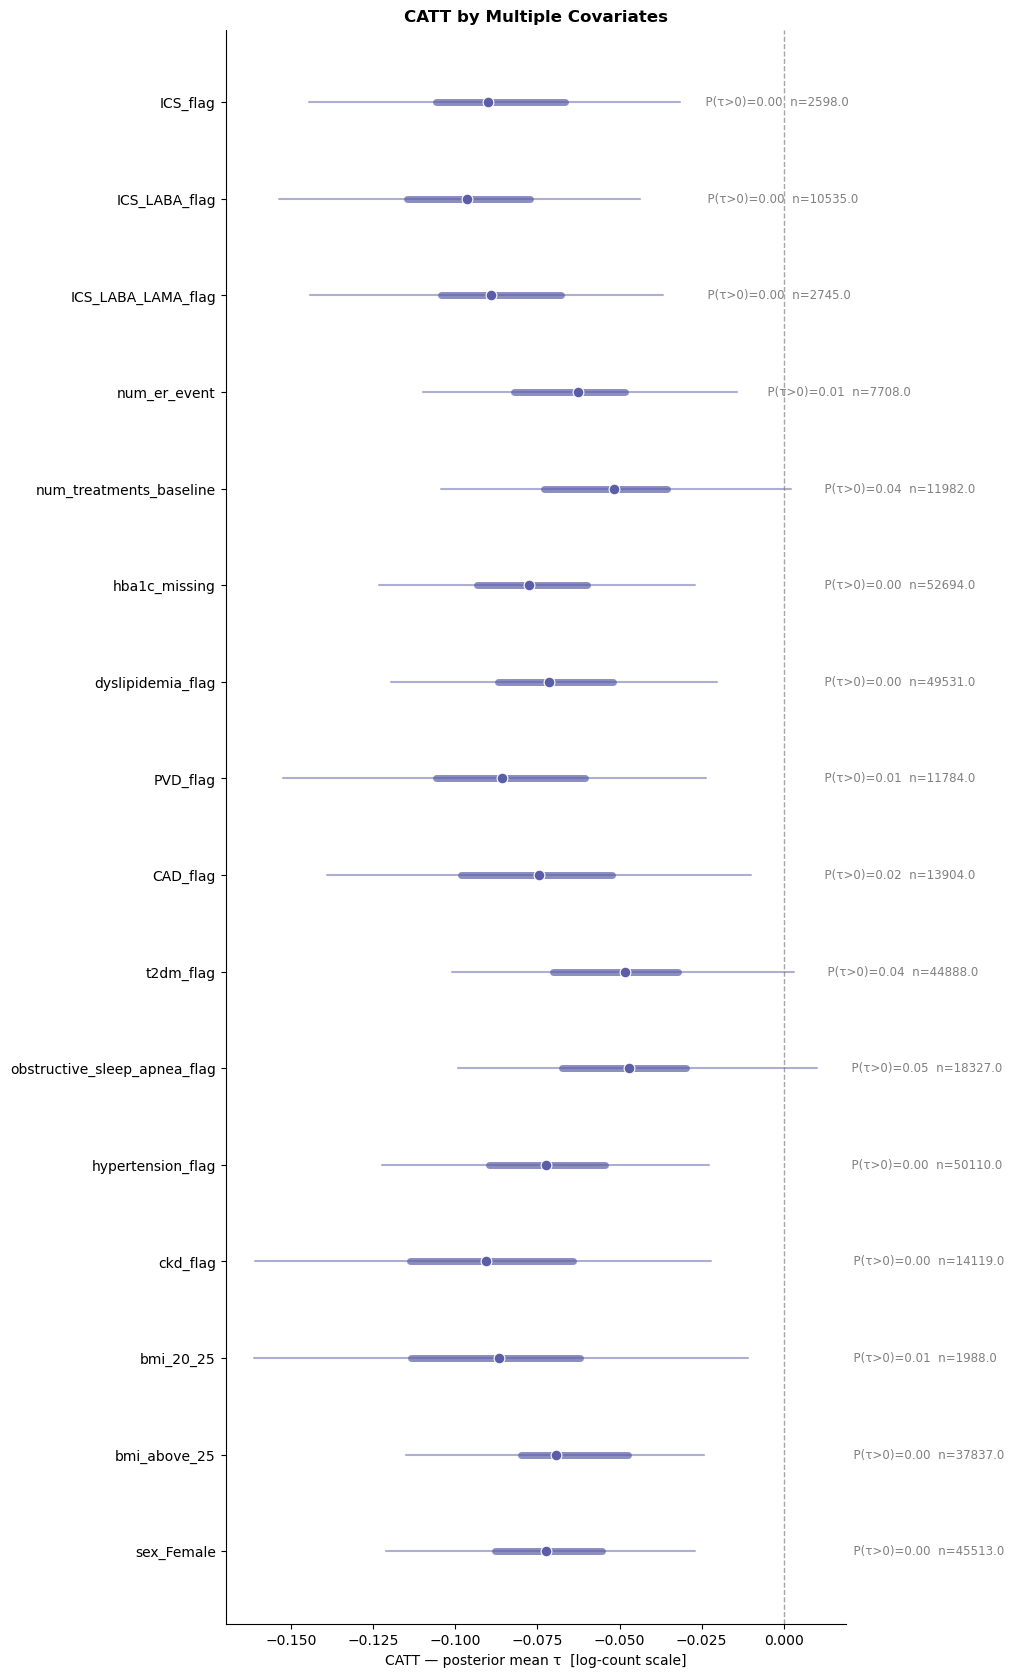

In [20]:
feature_list = [
    "ICS_flag", 
    "ICS_LABA_flag",
    "ICS_LABA_LAMA_flag",
    "num_er_event",
    "num_treatments_baseline",
    "hba1c_missing",
    "dyslipidemia_flag",
    "PVD_flag",
    "CAD_flag",
    "t2dm_flag",    
    "obstructive_sleep_apnea_flag",
    "hypertension_flag",
    "ckd_flag",
    "bmi_20_25",
    "bmi_above_25",
    "sex_Female",
    ]
ax, catt_df = plot_forest_multiple(
    trace_bcf, 
    X, 
    feature_names=feature_list, 
    ax=None)

## Decision Tree Proxy for CATTs that are clinically interpretable

In [10]:
from sklearn.tree import DecisionTreeRegressor
# 1. Take the mean estimated treatment effect for each patient
catt_estimates = trace_bcf.posterior["tau"].mean(dim=["chain", "draw"]).values
sorted_catt = np.sort(catt_estimates)
catt_rate_ratios = np.exp(catt_estimates)
y_proxy = catt_estimates

# Drop region columns if they exist, since they are not clinically interpretable
administrative_cols = [col for col in X.columns if 'region' in col.lower() or 'site' in col.lower()]
X_tau_clinical = X.drop(columns=administrative_cols)
feature_names_clinical = X_tau_clinical.columns

# 2. Fit a shallow Decision Tree to explain these effects using your covariates
# Max depth 4 keeps it clinically interpretable (16 subgroups max)
proxy_tree = DecisionTreeRegressor(max_depth=4)
proxy_tree.fit(X_tau_clinical, y_proxy)

# 3. Get the feature importance and visualize the rules
feature_importance = proxy_tree.feature_importances_
feature_importance_df = pd.DataFrame({
    "feature": feature_names_clinical,
    "importance": feature_importance
}).sort_values(by="importance", ascending=False)
feature_importance_df.head(10).reset_index(drop=True)

,feature,importance
0,age,0.518144
1,t2dm_flag,0.370387
2,gina_step,0.100103
3,obstructive_sleep_apnea_flag,0.011366
4,total_exac_count,0.000000
5,num_er_event,0.000000
6,hba1c_missing,0.000000
7,num_treatments_baseline,0.000000
8,num_outpatient_event,0.000000
9,ckd_flag,0.000000


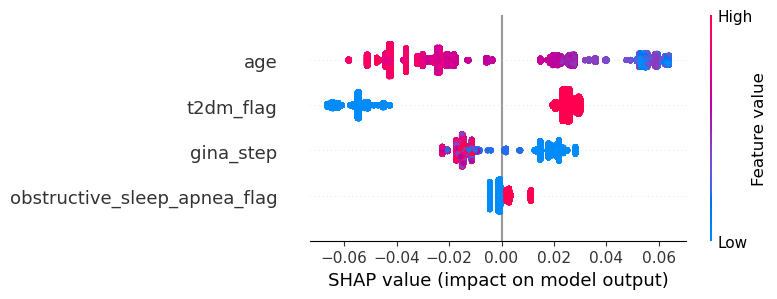

In [13]:
# SHAP values for the tree
import shap
explainer = shap.TreeExplainer(proxy_tree)
shap_values = explainer.shap_values(X_tau_clinical)

# Visualize the SHAP values
shap.summary_plot(shap_values, X_tau_clinical, feature_names=feature_names_clinical, max_display=4)


## GATES and CLANs

Building ITE-RD posterior arrays …
  ite_rd shape        : (8000, 65417)
  rd_treated shape    : (8000, 13547)
  mean(CATT)          : -0.00457

── A: GATES plot ──


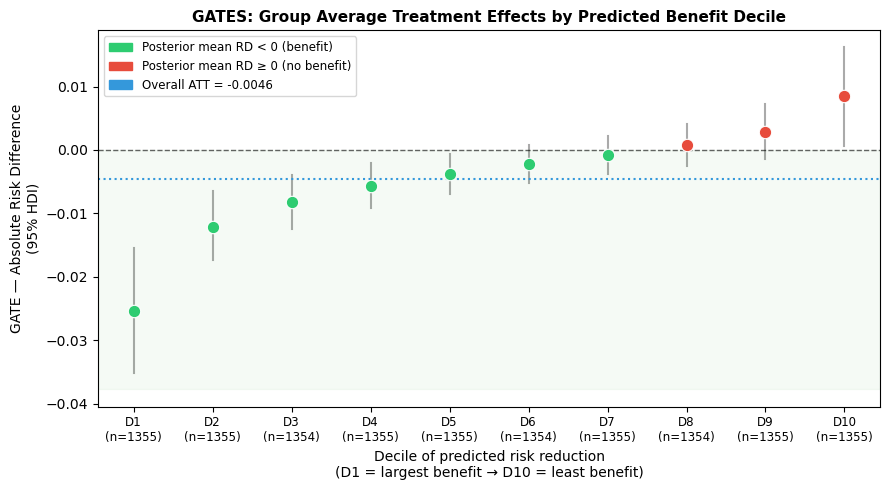

 decile    n  gate_mean        lo        hi  p_benefit
      1 1355  -0.025349 -0.035165 -0.015443   1.000000
      2 1355  -0.012058 -0.017310 -0.006535   1.000000
      3 1354  -0.008167 -0.012450 -0.003950   0.999875
      4 1355  -0.005614 -0.009207 -0.001992   0.998250
      5 1355  -0.003727 -0.006941 -0.000590   0.988375
      6 1354  -0.002174 -0.005157  0.000754   0.925875
      7 1355  -0.000779 -0.003776  0.002167   0.700125
      8 1354   0.000778 -0.002562  0.004167   0.322000
      9 1355   0.002881 -0.001381  0.007168   0.090125
     10 1355   0.008465  0.000622  0.016160   0.014125


In [12]:
# ── Step 0: (Re)build ITE-RD posterior ───────────────────────────────
print("Building ITE-RD posterior arrays …")
ite_rd, rd_treated, mean_rd_treated, treated_mask = build_ite_rd(
    trace_bcf, X_mu, X_tau, T, constant_intercept)
print(f"  ite_rd shape        : {ite_rd.shape}")
print(f"  rd_treated shape    : {rd_treated.shape}")
print(f"  mean(CATT)          : {rd_treated.mean():.5f}")

# ── A: GATES ─────────────────────────────────────────────────────────
print("\n── A: GATES plot ──")
gates_df = plot_gates(
    rd_treated, mean_rd_treated,
    n_deciles=10,
    save_path="fig_gates_rd.png"
)
print(gates_df.to_string(index=False))


In [ ]:
def print_clan_table(clan_df, top_pct=0.10):
    """Plain-text fallback for non-Jupyter environments."""
    pct_label = f"Top {int(top_pct * 100)}%"
    hdr = clan_df.columns.tolist()
    w = [36, 12, 26, 26, 20, 20]  # column widths for formatting
    sep = "─" * sum(w)
    print(f"\n{sep}")
    print(f"  CLAN Table — {pct_label} Maximum-Benefit Subgroup (D1) vs Rest of Treated")
    print(sep)
    print(f"{'Variable':<{w[0]}} {'Type':<{w[1]}} {hdr[2]:<{w[2]}} "
          f"{hdr[3]:<{w[3]}} {'Absolute Difference':>{w[4]}} {'SMD':>{w[5]}}")
    print(sep)
    for _, row in clan_df.iterrows():
        print(f"{row['Variable']:<{w[0]}} {row['Type']:<{w[1]}} "
              f"{row[hdr[2]]:<{w[2]}} {row[hdr[3]]:<{w[3]}} "
              f"{row['Absolute Difference']:>{w[4]}}"
              f"{row['SMD']:>{w[5]}}")
              
        
    print(sep + "\n")

In [19]:
# ── B: CLAN ──────────────────────────────────────────────────────────
print("\n── B: CLAN table ──")
clan_df = build_clan_table(
    mean_rd_treated, X, T,
    top_pct=0.10,
    smd_threshold=0.10
    
)
print_clan_table(clan_df, top_pct=0.10)


── B: CLAN table ──

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  CLAN Table — Top 10% Maximum-Benefit Subgroup (D1) vs Rest of Treated
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                             Type         D1 - high benefit (n=1355) Rest of treated (n=12192)   Absolute Difference                  SMD
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Unique Treatments - Baseline         continuous   3.74 ± 1.31                1.80 ± 1.30                                1.93                1.48
Exacerbation Count - Baseline        continuous   0.81 ± 0.80                0.12 ± 0.39                                0.70                1.11
GINA Step                            continuous

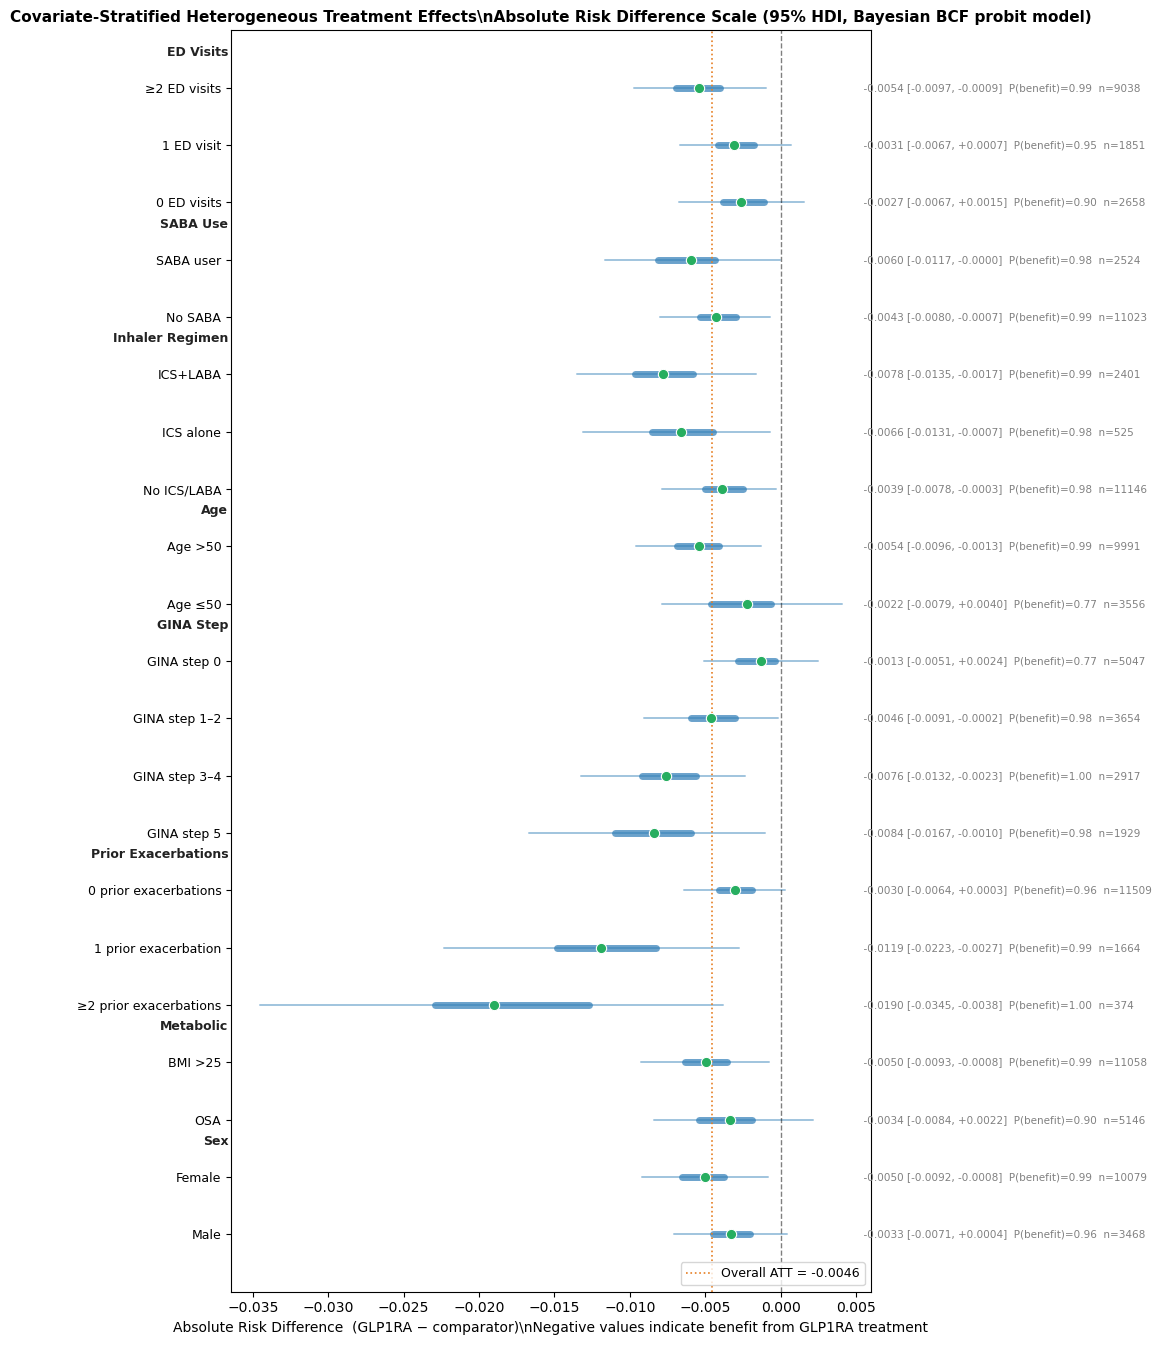

              group                  label     n      mean      lo95      hi95  p_benefit
          ED Visits           ≥2 ED visits  9038 -0.005446 -0.009717 -0.000944   0.992250
          ED Visits             1 ED visit  1851 -0.003081 -0.006651  0.000679   0.948250
          ED Visits            0 ED visits  2658 -0.002652 -0.006748  0.001541   0.897000
           SABA Use              SABA user  2524 -0.005951 -0.011678 -0.000016   0.975875
           SABA Use                No SABA 11023 -0.004259 -0.008002 -0.000678   0.987000
    Inhaler Regimen               ICS+LABA  2401 -0.007808 -0.013488 -0.001657   0.994000
    Inhaler Regimen              ICS alone   525 -0.006598 -0.013140 -0.000707   0.981875
    Inhaler Regimen            No ICS/LABA 11146 -0.003878 -0.007847 -0.000296   0.977000
                Age                Age >50  9991 -0.005415 -0.009611 -0.001330   0.993625
                Age                Age ≤50  3556 -0.002214 -0.007890  0.004043   0.772375
          

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# CELL C — HTE Forest Plot on the absolute Risk Difference scale
# Assumes: ite_rd, X, T, constant_intercept are in scope from Cell A
# ══════════════════════════════════════════════════════════════════════════

def rd_stratum(ite_rd, full_mask, T_arr, hdi_prob=0.95):
    """CATE among treated patients within full_mask."""
    mask = full_mask & T_arr.astype(bool)
    if mask.sum() < 20:
        return None
    draws      = ite_rd[:, mask].mean(axis=1)
    hdi_v      = az.hdi(draws, hdi_prob=hdi_prob)
    lo50, hi50 = az.hdi(draws, hdi_prob=0.50)
    return dict(mean=draws.mean(), lo95=hdi_v[0], hi95=hdi_v[1],
                lo50=lo50, hi50=hi50,
                p_benefit=float((draws < 0).mean()), n=int(mask.sum()))

Xd = X.reset_index(drop=True)

strata = [
    # ── Wang splits (label, group, mask) ─────────────────────────────
    ("≥2 ED visits",          "ED Visits",          (Xd["num_er_event"] >= 2).values),
    ("1 ED visit",            "ED Visits",          (Xd["num_er_event"] == 1).values),
    ("0 ED visits",           "ED Visits",          (Xd["num_er_event"] == 0).values),
    ("SABA user",             "SABA Use",           (Xd["SABA_flag"] == 1).values),
    ("No SABA",               "SABA Use",           (Xd["SABA_flag"] == 0).values),
    ("ICS+LABA",              "Inhaler Regimen",    (Xd["ICS_LABA_flag"] == 1).values),
    ("ICS alone",             "Inhaler Regimen",    ((Xd["ICS_flag"]==1)).values),
    ("No ICS/LABA",           "Inhaler Regimen",    (Xd["ICS_LABA_flag"] == 0).values),
    ("Age >50",               "Age",                (Xd["age"] > 50).values),
    ("Age ≤50",               "Age",                (Xd["age"] <= 50).values),
    # ── Additional ───────────────────────────────────────────────────
    ("GINA step 0",           "GINA Step",          (Xd["gina_step"] == 0).values),
    ("GINA step 1–2",         "GINA Step",          ((Xd["gina_step"]>=1)&(Xd["gina_step"]<=2)).values),
    ("GINA step 3–4",         "GINA Step",          ((Xd["gina_step"]>=3)&(Xd["gina_step"]<=4)).values),
    ("GINA step 5",           "GINA Step",          (Xd["gina_step"] == 5).values),
    ("0 prior exacerbations", "Prior Exacerbations",(Xd["total_exac_count"] == 0).values),
    ("1 prior exacerbation",  "Prior Exacerbations",(Xd["total_exac_count"] == 1).values),
    ("≥2 prior exacerbations","Prior Exacerbations",(Xd["total_exac_count"] >= 2).values),
    ("BMI >25",               "Metabolic",          (Xd["bmi_above_25"] == 1).values),
    ("OSA",                   "Metabolic",          (Xd["obstructive_sleep_apnea_flag"]==1).values),
    ("Female",                "Sex",                (Xd["sex_Female"] == 1).values),
    ("Male",                  "Sex",                (Xd["sex_Female"] == 0).values),
]

rows = []
for label, group, mask in strata:
    r = rd_stratum(ite_rd, mask, T)
    if r:
        rows.append({"label": label, "group": group, **r})

forest_df = pd.DataFrame(rows)

# ── Draw ──────────────────────────────────────────────────────────────────
n_r    = len(forest_df)
colour = "#2c7bb6"
fig, ax = plt.subplots(figsize=(11, max(6, 0.55 * n_r + 2)))

y_pos          = np.arange(n_r)[::-1]
current_group  = None

for i, (_, row) in enumerate(forest_df.iterrows()):
    y = y_pos[i]
    if row["group"] != current_group:
        current_group = row["group"]
        ax.text(-0.004, y + 0.62, row["group"],
                transform=ax.get_yaxis_transform(),
                ha="right", va="center",
                fontsize=9, fontweight="bold", color="#222222")
    ax.plot([row["lo95"], row["hi95"]], [y, y],
            color=colour, lw=1.4, alpha=0.45, solid_capstyle="round")
    ax.plot([row["lo50"], row["hi50"]], [y, y],
            color=colour, lw=5,   alpha=0.70, solid_capstyle="round")
    dot_c = "#27ae60" if row["mean"] < 0 else "#e74c3c"
    ax.scatter(row["mean"], y, s=55, color=dot_c, zorder=5,
               edgecolors="white", linewidths=0.8)
    ax.text(forest_df["hi95"].max() + 0.001, y,
            f"  {row['mean']:+.4f} [{row['lo95']:+.4f}, {row['hi95']:+.4f}]  "
            f"P(benefit)={row['p_benefit']:.2f}  n={row['n']}",
            va="center", fontsize=7.5, color="gray")

att_mean = ite_rd[:, T.astype(bool)].mean()
ax.axvline(0,        color="black",   lw=1,   ls="--", alpha=0.5)
ax.axvline(att_mean, color="#e67e22", lw=1.2, ls=":",
           label=f"Overall ATT = {att_mean:.4f}")

ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"].tolist(), fontsize=9)
ax.set_xlabel(
    "Absolute Risk Difference  (GLP1RA − comparator)\\n"
    "Negative values indicate benefit from GLP1RA treatment",
    fontsize=10)
ax.set_title(
    "Covariate-Stratified Heterogeneous Treatment Effects\\n"
    "Absolute Risk Difference Scale (95% HDI, Bayesian BCF probit model)",
    fontsize=11, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()
print(forest_df[["group","label","n","mean","lo95","hi95","p_benefit"]].to_string(index=False))